# Explorateur FFT — notebook autonome

Notebook **jetable**, indépendant de `interface.py` et non importé par `src/` : tu peux le supprimer à tout moment sans rien casser.

Il réutilise directement les fonctions du pipeline (`src/signal_processing/frequency.py`, `src/io/raw_file_loader.py`) pour :
1. Charger un signal directement depuis les fichiers `.txt` bruts d'un boîtier (pas encore ingérés dans le data lake Parquet),
2. Calculer sa FFT,
3. Tracer le spectre avec les **4 fréquences dominantes** annotées.

À lancer avec Jupyter depuis la racine du projet (`jupyter notebook` ou l'extension Jupyter de ton éditeur). Si Jupyter n'est pas installé : `pip install notebook ipykernel` (volontairement pas ajouté à `requirements.txt`, pour que ce notebook reste facile à retirer).

In [27]:
#%matplotlib widget
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Try to enable the interactive matplotlib backend.
# If ipympl is not installed, fall back to the default inline backend.
try:
    import ipympl  # pip install ipympl
    %matplotlib widget
except Exception:
    %matplotlib inline

# Comme les autres points d'entrée du projet (interface.py, to_data_lake.py),
# tout ce notebook suppose un cwd = racine du projet.
PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.io.raw_file_loader import load_all_oscillo_files
from src.signal_processing.frequency import (
    compute_top_n_dominant_frequencies_batch,
    time_seconds_from_axis,
)

## Paramètres — à éditer

In [28]:
DONNEES_BOITIER_PATH = "/home/aazzouzi/Projet_IA/Adapte2/VisiteAgroE2/Exploitation5_Chiché_AgroE2/Visite1/Données_Boitier/"

BOITIER = "boitier_1"   # ex: "boitier_1", "boitier_2", ... (dossiers sous Données_Boitier/)
VOIE = 1                  # 1, 2 ou 3 -> mappé sur channel_index = VOIE - 1 (colonnes numériques du fichier)

WINDOW_INDEX = 1          # quelle fenêtre analyser parmi celles chargées (voir cellule suivante)
TOP_N = 10                 # nombre de fréquences dominantes à extraire
FFT_XLIM_HZ = 200          # ex: 500 pour zoomer sur les basses fréquences ; None = spectre complet

# Paramètres de la DFT directe (même logique que le script de référence : somme directe des
# exponentielles complexes sur une plage de fréquences fixe, pas de FFT ni de fenêtrage de Hann)
FMIN_HZ = 10               # fréquence minimale
FMAX_HZ = 2500             # fréquence maximale
DF_HZ = 10               # résolution fréquentielle (Hz)

## Boîtiers / voies disponibles dans `Données_Boitier/`

Purement indicatif, pour t'aider à choisir les paramètres ci-dessus sans deviner.
Les fichiers `.txt` bruts d'un boîtier ne sont pas datés individuellement dans les
paramètres : `load_all_oscillo_files` charge tous les fichiers du dossier `Oscillo/`
d'un coup et les découpe en fenêtres par coupure temporelle (gap > 0.5s).

In [29]:
def list_available_oscillo(donnees_boitier_path=DONNEES_BOITIER_PATH):
    for boitier in sorted(os.listdir(donnees_boitier_path)):
        oscillo_dir = os.path.join(donnees_boitier_path, boitier, "Oscillo")
        if not os.path.isdir(oscillo_dir):
            continue
        files = sorted(f for f in os.listdir(oscillo_dir) if f.endswith((".txt", ".csv")))
        print(f"{boitier} : {len(files)} fichier(s)")
        for f in files:
            print(f"    {f}")

list_available_oscillo()

boitier_1 : 13 fichier(s)
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_11-10.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_11-11.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_11-41.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_12-11.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_12-41.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_13-11.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_13-41.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_14-11.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_14-41.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_15-11.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_15-41.txt
    Courant_Tension_FctOSCILLO_Boitier1_2025-01-21_16-11.txt
    FFT_2025-01-21_14-19-09.txt
boitier_2 : 10 fichier(s)
    Courant_Tension_FctOSCILLO_Boitier2_2025-01-21_12-36.txt
    Courant_Tension_FctOSCILLO_Boitier2_2025-01-21_12-37.txt
    Courant_Tension_FctOSCILLO_Boitier2_2025-01-21_12-39.txt
 

## Chargement du signal (même loader que le pipeline en mode "fichiers bruts")

In [30]:
OSCILLO_DIR = os.path.join(DONNEES_BOITIER_PATH, BOITIER, "Oscillo")
CHANNEL_INDEX = VOIE - 1

windows, time_arrays = load_all_oscillo_files(OSCILLO_DIR, CHANNEL_INDEX)

windows = windows
time_arrays = time_arrays

n_windows = len(windows)
print(f"{n_windows} fenêtre(s) chargée(s) pour {BOITIER} / voie_{VOIE} ({OSCILLO_DIR})")
for i in range(n_windows):
    print(f"  fenêtre {i} : {len(windows[i])} pts, début = {time_arrays[i][0]}")

--- Analyse du dossier : '/home/aazzouzi/Projet_IA/Adapte2/VisiteAgroE2/Exploitation5_Chiché_AgroE2/Visite1/Données_Boitier/boitier_1/Oscillo' ---

--- Chargement terminé : 114 fenêtres récupérées ---
114 fenêtre(s) chargée(s) pour boitier_1 / voie_1 (/home/aazzouzi/Projet_IA/Adapte2/VisiteAgroE2/Exploitation5_Chiché_AgroE2/Visite1/Données_Boitier/boitier_1/Oscillo)
  fenêtre 0 : 5000 pts, début = 1737457825908427000
  fenêtre 1 : 5000 pts, début = 1737457832233146000
  fenêtre 2 : 5000 pts, début = 1737457908748541000
  fenêtre 3 : 5000 pts, début = 1737457910647124000
  fenêtre 4 : 5000 pts, début = 1737457912525893000
  fenêtre 5 : 5000 pts, début = 1737457916171544000
  fenêtre 6 : 5000 pts, début = 1737457918037560000
  fenêtre 7 : 5000 pts, début = 1737457939231277000
  fenêtre 8 : 5000 pts, début = 1737457941084529000
  fenêtre 9 : 5000 pts, début = 1737457942951621000
  fenêtre 10 : 5000 pts, début = 1737457944810921000
  fenêtre 11 : 5000 pts, début = 1737457946676641000
  fen

## FFT et fréquences dominantes — navigation interactive sur toutes les fenêtres

Les fréquences dominantes annotées sur le graphe sont calculées avec `compute_top_n_dominant_frequencies_batch` — exactement la fonction utilisée par le pipeline (`src/signal_processing/frequency.py`).

Le spectre tracé, lui, utilise une **DFT directe** sur une plage de fréquences fixe (`FMIN_HZ` à `FMAX_HZ`, pas `DF_HZ`) — même logique que le script de référence : somme directe de `tension * exp(-j*2*pi*f*t)` pour chaque fréquence, sans FFT ni fenêtrage de Hann, juste vectorisée avec NumPy pour rester rapide.

Le slider ci-dessous permet de parcourir **toutes** les fenêtres chargées, une par une. Le graphe utilise le backend interactif `ipympl` (`%matplotlib widget`) : molette ou pincement pour zoomer sur le spectre, glisser pour déplacer la vue, bouton "maison" de la toolbar pour réinitialiser. Le zoom appliqué sur le spectre est conservé quand tu changes de fenêtre.

IntSlider(value=1, continuous_update=False, description='Fenêtre', layout=Layout(width='700px'), max=113)

Output()

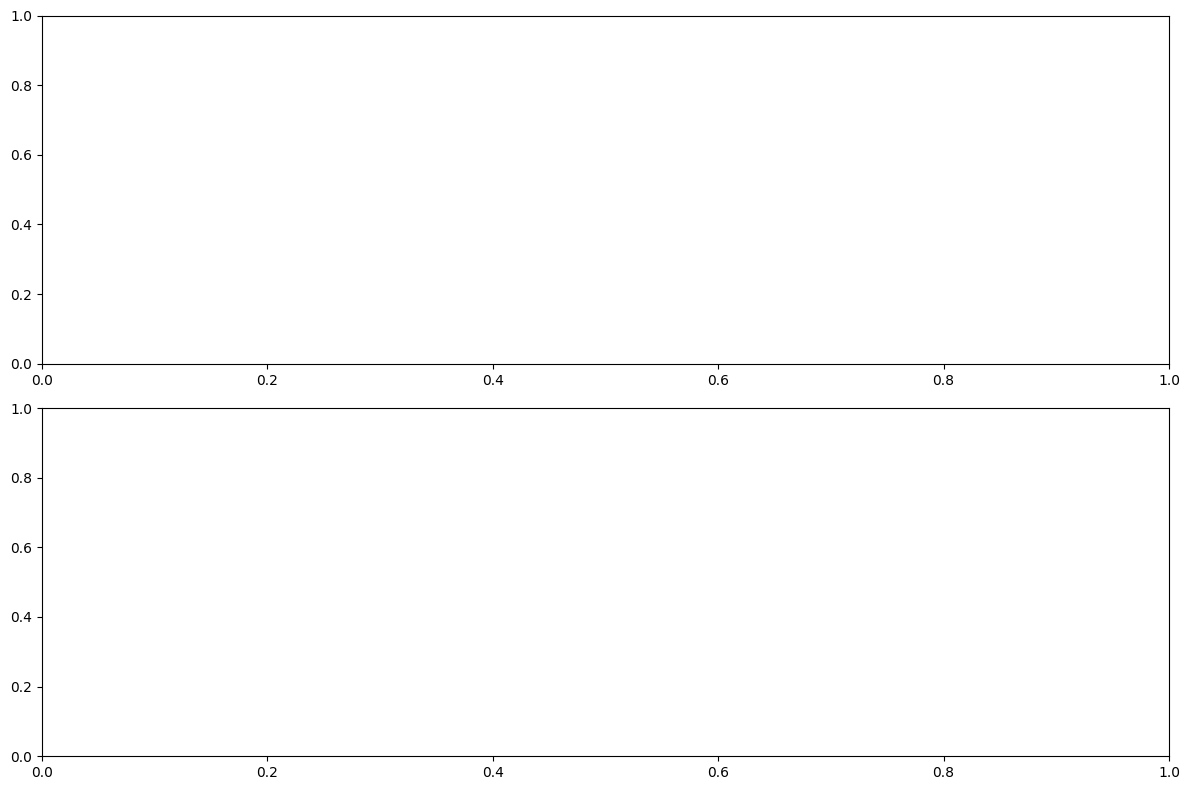

In [ ]:
def compute_window_fft(window_index):
    signal = windows[window_index]
    time_axis = time_arrays[window_index]

    t_secs = time_seconds_from_axis(time_axis)
    t_rel = t_secs - t_secs[0]
    duration = t_secs[-1] - t_secs[0]

    # DFT directe sur une plage de fréquences fixe [FMIN_HZ, FMAX_HZ] avec un pas DF_HZ :
    # même logique que le script de référence (somme directe de tension * exp(-j*2*pi*f*t)),
    # vectorisée ici avec NumPy au lieu des boucles Python imbriquées d'origine.
    freqs = np.arange(FMIN_HZ, FMAX_HZ + DF_HZ, DF_HZ)
    phase = np.exp(-2j * np.pi * np.outer(freqs, t_rel))
    dft = phase @ signal
    spectrum = np.abs(2 / (len(signal) - 1) * dft)

    top_freqs = compute_top_n_dominant_frequencies_batch(
        signal[None, :], time_axis[None, :], top_n=TOP_N
    )[0]

    return signal, t_secs, duration, freqs, spectrum, top_freqs


fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(12, 8))
fig.tight_layout()
_view_state = {"initialized": False}
_colors = ["red", "orange", "green", "purple"]

def update_plot(window_index):
    fft_xlim = ax_fft.get_xlim() if _view_state["initialized"] else None

    signal, t_secs, duration, freqs, spectrum, top_freqs = compute_window_fft(window_index)
    fs_estimee = (len(signal) - 1) / duration

    ax_time.clear()
    ax_time.plot(t_secs * 1000, signal, linewidth=0.8)
    ax_time.set_xlabel("Temps (ms)")
    ax_time.set_ylabel("Amplitude")
    ax_time.set_title(
        f"Signal — {BOITIER} / voie_{VOIE} / fenêtre {window_index}/{n_windows - 1} "
        f"({len(signal)} pts, {duration * 1000:.1f} ms, fs≈{fs_estimee:.0f} Hz)"
    )

    ax_fft.clear()
    ax_fft.plot(freqs, spectrum, linewidth=0.8, color="steelblue")
    for i, f in enumerate(top_freqs):
        if f <= 0:
            continue
        ax_fft.axvline(f, color=_colors[i % len(_colors)], linestyle="--", linewidth=1,
                        label=f"#{i + 1}: {f:.1f} Hz")
    ax_fft.set_xlabel("Fréquence (Hz)")
    ax_fft.set_ylabel("Amplitude")
    ax_fft.set_title("Spectre DFT directe — molette/glisser pour zoomer (conservé entre fenêtres)")
    ax_fft.set_xlim(fft_xlim if fft_xlim else (0, FFT_XLIM_HZ if FFT_XLIM_HZ else freqs[-1]))
    ax_fft.legend()

    _view_state["initialized"] = True
    fig.canvas.draw_idle()

    print("Fréquences dominantes (Hz) :")
    for i, f in enumerate(top_freqs, start=1):
        print(f"  {i}. {f:.2f} Hz")


window_slider = widgets.IntSlider(
    value=min(WINDOW_INDEX, n_windows - 1), min=0, max=n_windows - 1, step=1,
    description="Fenêtre", continuous_update=False,
    layout=widgets.Layout(width="700px"),
)
output = widgets.interactive_output(update_plot, {"window_index": window_slider})
display(window_slider, output)